In [1]:
# DTG analysis

import os
# os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import h5py
import numpy as np
import h5flow
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
def thd_correct(array):
    
    array_shape = np.shape(array)[-1]
    num_bins = int((array_shape // 25)+1)
    indices = np.arange(0, num_bins) * 25  # (39,)
    start_indices, end_indices = indices[:-1], indices[1:]  # (39,)

    segment_range = np.arange(25)  # Shape: (25,)
    index_array = start_indices[:, None] + segment_range  # Shape: (39, 25)

    # Extract data using advanced indexing
    sliced_data = array[..., index_array]

    ranges = np.abs(np.ptp(sliced_data, axis=-1))
    #ranges = np.ptp(sliced_data, axis=-1)  # Compute range (n, 8, 64, 39)
    means = np.mean(sliced_data, axis=-1)  # Compute mean (n, 8, 64, 39)

    # Find ordering based on the smallest range
    smallest_ordering = np.argsort(ranges, axis=-1)  # Shape (n, 8, 64, 39)
    # Mask zero ranges
    mask_zero = (ranges != 0)
    ranges = np.where(mask_zero, ranges, np.nan)
    means = np.where(mask_zero, means, np.nan)

    # Sort means using the ordering
    sorted_means = np.take_along_axis(means, smallest_ordering, axis=-1)  # Shape (n, 8, 64, 39)
    sorted_range = np.take_along_axis(ranges, smallest_ordering, axis=-1)
    # Compute average of 2nd and 3rd smallest means (nanmean ignores zero-range segments)
    average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)  # Shape (n, 8, 64)
    # Fallback for channels where every segment had zero range (e.g. dead/unused channels):
    # their corrected waveform should be all zeros, so use the raw channel mean as baseline.
    fallback_mean = np.mean(array, axis=-1)  # Shape (n, 8, 64)
    average_mean = np.where(np.isnan(average_mean), fallback_mean, average_mean)
    expanded_mean = average_mean[..., None] 
    broadcasted_mean = np.tile(expanded_mean, (1, array_shape))  
    filtered_wvfm = array - broadcasted_mean

    return filtered_wvfm

In [3]:
def tag_dark_counts(N_Files):

     file_num = 0
     combined_sum_wvfms = np.zeros((8,2,500), dtype=np.float64)
     #count = np.zeros((8,64))
     sipm_channels = ([4,5,6,7,8,9] + \
                     [10,11,12,13,14,15] + \
                     [20,21,22,23,24,25] + \
                     [26,27,28,29,30,31] + \
                     [36,37,38,39,40,41] + \
                     [42,43,44,45,46,47] + \
                     [52,53,54,55,56,57] + \
                     [58,59,60,61,62,63])
     start_value = 736
     for Nf in range(N_Files):
          file = f'/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin2/two_trig_40us_period_500tick/hv_65kV_beamC_25uA/dtg_30min_thenDecay/mpd_run_data_rctl_979_p{start_value+file_num}.FLOW.hdf5'
          if file_num < N_Files: #508:
               print('file number:', file_num)
               file_num += 1
               if not os.path.isfile(file):
                    print('File does not exist:', file)
                    continue
               else:
                    with h5py.File(file, 'r') as h5:
                         offbeam_wvfm_v1 =  h5['light/wvfm/data']['samples'][0:100,:,sipm_channels,:]
                         offbeam_wvfm_v2 =  thd_correct(offbeam_wvfm_v1)
                         
                         del offbeam_wvfm_v1
                         sum_bychan = np.sum(offbeam_wvfm_v2, axis=2)
                         # print(sum_bychan)
                         #sum_bychan = np.nan_to_num(sum_bychan, nan=0)
                         beam_start_mask = (np.mean(sum_bychan[:,7,0:50], axis=-1) < np.mean(sum_bychan[:,7,400:500], axis=-1))
                         beam_end_mask = (np.mean(sum_bychan[:,7,0:50], axis=-1) > np.mean(sum_bychan[:,7,400:500], axis=-1))
                         print('Beam Start Events:', np.sum(beam_start_mask))
                         print('Beam End Events:', np.sum(beam_end_mask))
                         print(f'Hopefully {np.sum(beam_start_mask)+np.sum(beam_end_mask)} is equal to total events: {np.shape(sum_bychan)[0]}')
                         sum_start_events = np.sum(sum_bychan[beam_start_mask==1], axis=0)
                         sum_end_events = np.sum(sum_bychan[beam_end_mask==1], axis=0)
                         normalized_start_events = (sum_start_events / np.sum(beam_start_mask))
                         normalized_end_events = (sum_end_events / np.sum(beam_end_mask))
                         print(np.shape(normalized_end_events))
                         for adc in range(8):
                              combined_sum_wvfms[adc,0,:] += normalized_start_events[adc,:]
                              combined_sum_wvfms[adc,1,:] += normalized_end_events[adc,:]
     return combined_sum_wvfms

In [4]:
average_means_evt = tag_dark_counts(5)

file number: 0


/tmp/ipykernel_473440/1021557053.py:29: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)  # Shape (n, 8, 64)


Beam Start Events: 79
Beam End Events: 21
Hopefully 100 is equal to total events: 100
(8, 500)
file number: 1
Beam Start Events: 78
Beam End Events: 22
Hopefully 100 is equal to total events: 100
(8, 500)
file number: 2
Beam Start Events: 78
Beam End Events: 22
Hopefully 100 is equal to total events: 100
(8, 500)
file number: 3
Beam Start Events: 68
Beam End Events: 32
Hopefully 100 is equal to total events: 100
(8, 500)
file number: 4
Beam Start Events: 71
Beam End Events: 29
Hopefully 100 is equal to total events: 100
(8, 500)


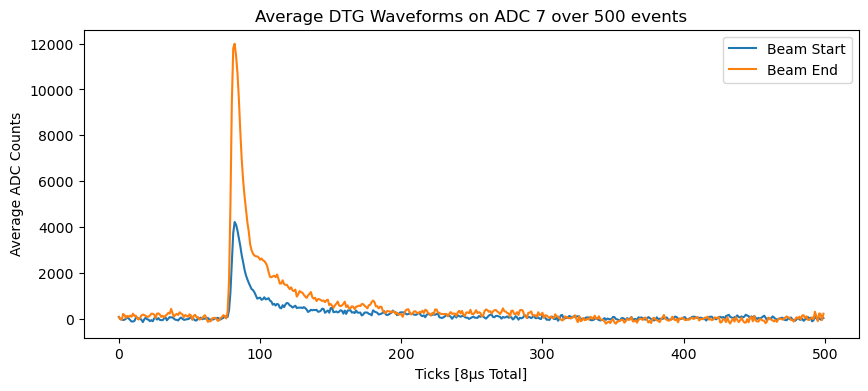

In [5]:
fig = plt.figure(figsize=(10,4))
plt.plot(np.arange(0,500,1), np.nan_to_num(average_means_evt[2,0,:], nan=0), label='Beam Start')
#print(average_means_evt)
plt.plot(np.arange(0,500,1), np.nan_to_num(average_means_evt[2,1,:], nan=0), label='Beam End')
plt.title('Average DTG Waveforms on ADC 7 over 500 events')
plt.xlabel('Ticks [8μs Total]')
plt.ylabel('Average ADC Counts')
plt.legend()
plt.show()

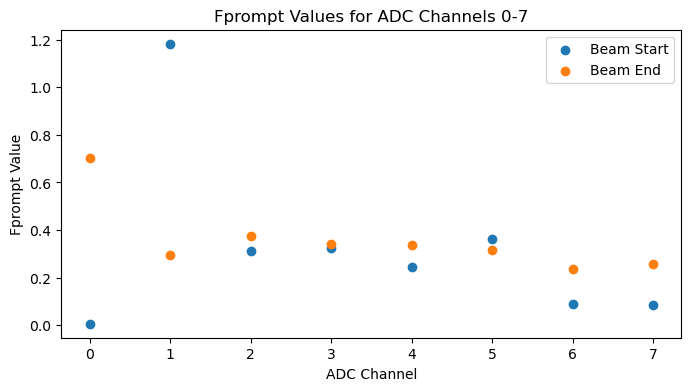

In [6]:
# calculate the fprompt for adc in range(8):
fprompt_values = np.zeros((8,2))
for adc in range(8):
     fprompt_values[adc,0] = np.sum(average_means_evt[adc,0,80:90]) / np.sum(average_means_evt[adc,0,80:500])
     fprompt_values[adc,1] = np.sum(average_means_evt[adc,1,80:90]) / np.sum(average_means_evt[adc,1,80:500])
plt.figure(figsize=(8,4))
plt.scatter(np.arange(8), fprompt_values[:,0], label='Beam Start')
plt.scatter(np.arange(8), fprompt_values[:,1], label='Beam End')
plt.xlabel('ADC Channel')
plt.ylabel('Fprompt Value')
plt.title('Fprompt Values for ADC Channels 0-7')
plt.xticks(np.arange(8))
plt.legend()
plt.show()

Global max raw ADC value : 32764
Global min raw ADC value : -32116
99th percentile per-event max: 32764
Events at global max         : 6042


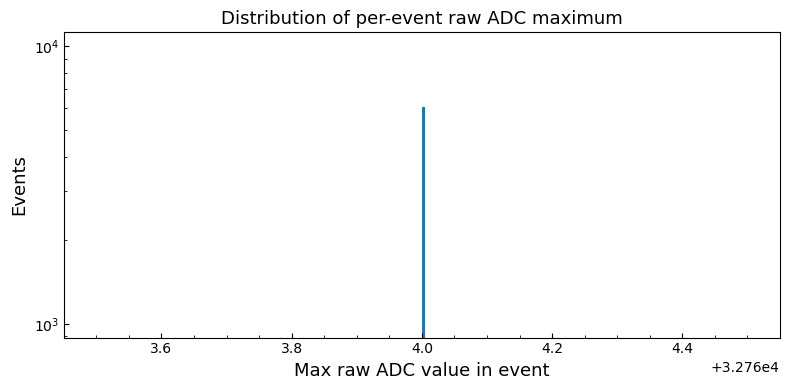

In [7]:
# Quick check: what is the actual ADC saturation value?
# Opens one file, reads raw samples, prints the maximum and plots its distribution.

check_file = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin2/two_trig_40us_period_500tick/hv_65kV_beamC_25uA/dtg_30min_thenDecay/mpd_run_data_rctl_978_p19.FLOW.hdf5'
_f = h5flow.data.H5FlowDataManager(check_file, mode="r")
try:
    raw_check = _f['/light/wvfm/data']['samples'][:, :, :, :500]
finally:
    _f.finish()

event_max = raw_check.reshape(len(raw_check), -1).max(axis=-1)  # one value per event

print(f"Global max raw ADC value : {raw_check.max()}")
print(f"Global min raw ADC value : {raw_check.min()}")
print(f"99th percentile per-event max: {np.percentile(event_max, 99):.0f}")
print(f"Events at global max         : {(raw_check == raw_check.max()).any(axis=(-1,-2,-3)).sum()}")

plt.figure(figsize=(8, 4))
plt.hist(event_max, bins=200)
plt.xlabel("Max raw ADC value in event", fontsize=13)
plt.ylabel("Events", fontsize=13)
plt.title("Distribution of per-event raw ADC maximum", fontsize=13)
plt.yscale("log")
plt.minorticks_on()
plt.tick_params(direction="in", which="both")
plt.tight_layout()
plt.show()
del raw_check


/tmp/ipykernel_473440/1021557053.py:29: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)  # Shape (n, 8, 64)


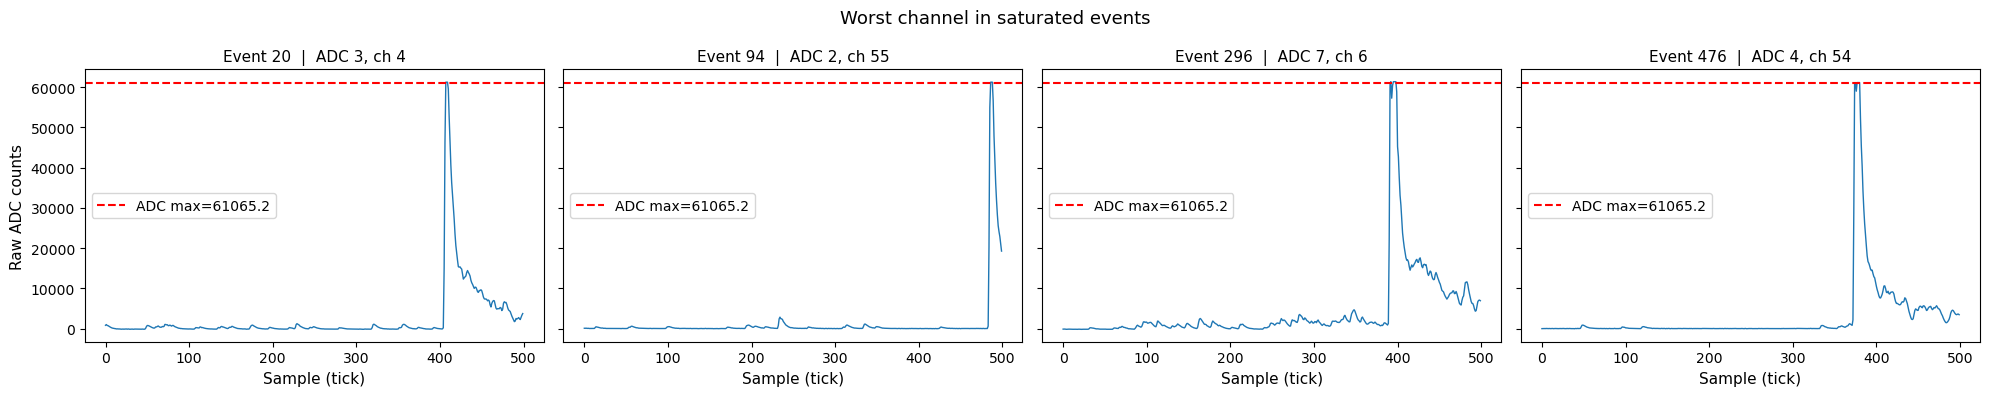

Total saturated events : 40 / 6042


In [8]:
# Inspect actual waveforms to confirm saturation visually.
# Re-loads the file (raw_check was deleted above to save memory).

_f = h5flow.data.H5FlowDataManager(check_file, mode="r")
try:
    raw_check = _f['/light/wvfm/data']['samples'][:, :, :, :500]
finally:
    _f.finish()

raw_check = thd_correct(raw_check)
sat_val = raw_check.max() - 500

# Find which events contain at least one saturated sample
sat_events = np.where(
    (raw_check >= sat_val).any(axis=(-1, -2, -3))
)[0]

# For each of the first 4 saturated events: find the worst ADC+channel and plot it
n_show = 4#min(4, len(sat_events))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4), sharey=True)
if n_show == 1:
    axes = [axes]

for ax, ev_idx in zip(axes, sat_events[:n_show]):
    wvfm = raw_check[ev_idx]          # shape: (n_adc, n_chan, n_samp)
    # Find the ADC+channel with the highest peak
    ch_max = wvfm.reshape(-1, wvfm.shape[-1]).max(axis=-1).argmax()
    adc_i, ch_i = divmod(ch_max, wvfm.shape[1])
    trace = wvfm[adc_i, ch_i]

    ax.plot(trace, lw=1)
    ax.axhline(sat_val, color="red", lw=1.5, ls="--", label=f"ADC max={sat_val}")
    ax.set_title(f"Event {ev_idx}  |  ADC {adc_i}, ch {ch_i}", fontsize=11)
    ax.set_xlabel("Sample (tick)", fontsize=11)
    ax.legend(fontsize=10)

axes[0].set_ylabel("Raw ADC counts", fontsize=11)
plt.suptitle("Worst channel in saturated events", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total saturated events : {len(sat_events)} / {len(raw_check)}")
del raw_check


In [9]:
h5flow.data.H5FlowDataManager(check_file, mode="r")['light/events/data'].dtype.names

('id', 'event', 'sn', 'utime_ms', 'tai_ns', 'wvfm_valid', 'trig_type')

In [10]:
# Light trap definitions — maps (adc, channels) → trap name, tpc, position, type
TRAP_NAME_MAP = [
    dict(adc=0, channels=[4,5,6,7,8,9],      name="ACL 2.01", tpc=0, z_side="-z", position="bottom"),
    dict(adc=0, channels=[10,11,12,13,14,15], name="ACL 2.02", tpc=0, z_side="-z", position="top"),
    dict(adc=0, channels=[20,21,22,23,24,25], name="ACL 2.03", tpc=0, z_side="+z", position="bottom"),
    dict(adc=0, channels=[26,27,28,29,30,31], name="ACL 2.04", tpc=0, z_side="+z", position="top"),
    dict(adc=0, channels=[52,53,54,55,56,57], name="ACL 2.05", tpc=1, z_side="-z", position="bottom"),
    dict(adc=0, channels=[58,59,60,61,62,63], name="ACL 2.06", tpc=1, z_side="-z", position="top"),
    dict(adc=0, channels=[36,37,38,39,40,41], name="ACL 2.07", tpc=1, z_side="+z", position="bottom"),
    dict(adc=0, channels=[42,43,44,45,46,47], name="ACL 2.08", tpc=1, z_side="+z", position="top"),
    dict(adc=1, channels=[4,5,6,7,8,9],      name="LCM 100-102", tpc=0, z_side="-z", position="bottom"),
    dict(adc=1, channels=[10,11,12,13,14,15], name="LCM 103-105", tpc=0, z_side="-z", position="top"),
    dict(adc=1, channels=[20,21,22,23,24,25], name="LCM 106-108", tpc=0, z_side="+z", position="bottom"),
    dict(adc=1, channels=[26,27,28,29,30,31], name="LCM 109-111", tpc=0, z_side="+z", position="top"),
    dict(adc=1, channels=[52,53,54,55,56,57], name="LCM 112-114", tpc=1, z_side="-z", position="bottom"),
    dict(adc=1, channels=[58,59,60,61,62,63], name="LCM 115-117", tpc=1, z_side="-z", position="top"),
    dict(adc=1, channels=[36,37,38,39,40,41], name="LCM 118-120", tpc=1, z_side="+z", position="bottom"),
    dict(adc=1, channels=[42,43,44,45,46,47], name="LCM 121-123", tpc=1, z_side="+z", position="top"),
    dict(adc=2, channels=[4,5,6,7,8,9],      name="ACL 2.09", tpc=2, z_side="-z", position="bottom"),
    dict(adc=2, channels=[10,11,12,13,14,15], name="ACL 2.10", tpc=2, z_side="-z", position="top"),
    dict(adc=2, channels=[20,21,22,23,24,25], name="ACL 2.11", tpc=2, z_side="+z", position="bottom"),
    dict(adc=2, channels=[26,27,28,29,30,31], name="ACL 2.12", tpc=2, z_side="+z", position="top"),
    dict(adc=2, channels=[52,53,54,55,56,57], name="ACL 2.13", tpc=3, z_side="-z", position="bottom"),
    dict(adc=2, channels=[58,59,60,61,62,63], name="ACL 2.14", tpc=3, z_side="-z", position="top"),
    dict(adc=2, channels=[36,37,38,39,40,41], name="ACL 2.15", tpc=3, z_side="+z", position="bottom"),
    dict(adc=2, channels=[42,43,44,45,46,47], name="ACL 2.16", tpc=3, z_side="+z", position="top"),
    dict(adc=3, channels=[20,21,22,23,24,25], name="LCM 124-126", tpc=2, z_side="-z", position="bottom"),
    dict(adc=3, channels=[26,27,28,29,30,31], name="LCM 127-129", tpc=2, z_side="-z", position="top"),
    dict(adc=3, channels=[4,5,6,7,8,9],      name="LCM 130-132", tpc=2, z_side="+z", position="bottom"),
    dict(adc=3, channels=[10,11,12,13,14,15], name="LCM 133-135", tpc=2, z_side="+z", position="top"),
    dict(adc=3, channels=[52,53,54,55,56,57], name="LCM 136-138", tpc=3, z_side="-z", position="bottom"),
    dict(adc=3, channels=[58,59,60,61,62,63], name="LCM 139-141", tpc=3, z_side="-z", position="top"),
    dict(adc=3, channels=[36,37,38,39,40,41], name="LCM 142-144", tpc=3, z_side="+z", position="bottom"),
    dict(adc=3, channels=[42,43,44,45,46,47], name="LCM 145-147", tpc=3, z_side="+z", position="top"),
    dict(adc=4, channels=[42,43,44,45,46,47], name="ACL 2.17",    tpc=4, z_side="-z", position="bottom"),
    dict(adc=4, channels=[36,37,38,39,40,41], name="ACL 2.18",    tpc=4, z_side="-z", position="top"),
    dict(adc=4, channels=[52,53,54,55,56,57], name="LCM 148-150", tpc=4, z_side="+z", position="bottom"),
    dict(adc=4, channels=[58,59,60,61,62,63], name="LCM 151-153", tpc=4, z_side="+z", position="top"),
    dict(adc=4, channels=[26,27,28,29,30,31], name="ACL 2.19",    tpc=5, z_side="-z", position="bottom"),
    dict(adc=4, channels=[20,21,22,23,24,25], name="ACL 2.20",    tpc=5, z_side="-z", position="top"),
    dict(adc=4, channels=[10,11,12,13,14,15], name="ACL 2.21",    tpc=5, z_side="+z", position="bottom"),
    dict(adc=4, channels=[4,5,6,7,8,9],      name="ACL 2.22",    tpc=5, z_side="+z", position="top"),
    dict(adc=5, channels=[42,43,44,45,46,47], name="LCM 154-156", tpc=4, z_side="-z", position="bottom"),
    dict(adc=5, channels=[58,59,60,61,62,63], name="ACL 2.23",    tpc=4, z_side="+z", position="bottom"),
    dict(adc=5, channels=[52,53,54,55,56,57], name="ACL 2.24",    tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[36,37,38,39,40,41], name="LCM 157-159", tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[26,27,28,29,30,31], name="LCM 160-162", tpc=5, z_side="-z", position="bottom"),
    dict(adc=5, channels=[20,21,22,23,24,25], name="LCM 163-165", tpc=5, z_side="-z", position="top"),
    dict(adc=5, channels=[10,11,12,13,14,15], name="LCM 166-168", tpc=5, z_side="+z", position="bottom"),
    dict(adc=5, channels=[4,5,6,7,8,9],      name="LCM 169-171", tpc=5, z_side="+z", position="top"),
    dict(adc=6, channels=[4,5,6,7,8,9],      name="ACL 2.25", tpc=6, z_side="-z", position="bottom"),
    dict(adc=6, channels=[10,11,12,13,14,15], name="ACL 2.26", tpc=6, z_side="-z", position="top"),
    dict(adc=6, channels=[20,21,22,23,24,25], name="ACL 2.27", tpc=6, z_side="+z", position="bottom"),
    dict(adc=6, channels=[26,27,28,29,30,31], name="ACL 2.28", tpc=6, z_side="+z", position="top"),
    dict(adc=6, channels=[52,53,54,55,56,57], name="ACL 2.29", tpc=7, z_side="-z", position="bottom"),
    dict(adc=6, channels=[58,59,60,61,62,63], name="ACL 2.30", tpc=7, z_side="-z", position="top"),
    dict(adc=6, channels=[36,37,38,39,40,41], name="ACL 2.31", tpc=7, z_side="+z", position="bottom"),
    dict(adc=6, channels=[42,43,44,45,46,47], name="ACL 2.32", tpc=7, z_side="+z", position="top"),
    dict(adc=7, channels=[4,5,6,7,8,9],      name="LCM 172-174", tpc=6, z_side="-z", position="bottom"),
    dict(adc=7, channels=[10,11,12,13,14,15], name="LCM 175-177", tpc=6, z_side="-z", position="top"),
    dict(adc=7, channels=[20,21,22,23,24,25], name="LCM 178-180", tpc=6, z_side="+z", position="bottom"),
    dict(adc=7, channels=[26,27,28,29,30,31], name="LCM 181-183", tpc=6, z_side="+z", position="top"),
    dict(adc=7, channels=[52,53,54,55,56,57], name="LCM 184-186", tpc=7, z_side="-z", position="bottom"),
    dict(adc=7, channels=[58,59,60,61,62,63], name="LCM 187-189", tpc=7, z_side="-z", position="top"),
    dict(adc=7, channels=[36,37,38,39,40,41], name="LCM 190-192", tpc=7, z_side="+z", position="bottom"),
    dict(adc=7, channels=[42,43,44,45,46,47], name="LCM 193-195", tpc=7, z_side="+z", position="top"),
]


def sum_to_traps(samples, trap_map):
    """Sum ADC channels within each light trap.
    samples  : (n_events, 8, 64, n_ticks)
    returns  : (n_events, n_traps, n_ticks)
    """
    n_ev, _, _, n_t = samples.shape
    out = np.zeros((n_ev, len(trap_map), n_t), dtype=np.float64)
    for i, entry in enumerate(trap_map):
        out[:, i, :] = samples[:, entry["adc"], :, :][:, entry["channels"], :].sum(axis=1)
    return out


def sum_to_tpcs(trap_wvfms, trap_map):
    """Sum trap waveforms within each TPC.
    trap_wvfms : (n_events, n_traps, n_ticks)
    returns     : (n_events, 8, n_ticks)
    """
    n_ev, _, n_t = trap_wvfms.shape
    out = np.zeros((n_ev, 8, n_t), dtype=np.float64)
    for i, entry in enumerate(trap_map):
        out[:, entry["tpc"], :] += trap_wvfms[:, i, :]
    return out


In [11]:
def find_valid_triggers(samples):
    pmt_wvfm_v2 = samples[:, :]*(-0.25) # The PMT pulse has negative polarity

    noise_sum_all = np.sum(pmt_wvfm_v2[:,5:100], axis=-1)
    noise_sum_fast = np.sum(pmt_wvfm_v2[:,5:18], axis=-1)

    fast_light = np.sum(pmt_wvfm_v2[:,105:118], axis=-1) - noise_sum_fast
    all_light = np.sum(pmt_wvfm_v2[:,105:200], axis=-1) - noise_sum_all
    ratio = fast_light / all_light

    fprompt_mask = (ratio > 0.001) & (ratio < 0.2)
    thd_mask = (pmt_wvfm_v2[:,100:300] > 70)
    pick_out_low = (np.sum(thd_mask[:,5:120], axis=-1) <= 15)
    return fprompt_mask & (~pick_out_low)


def extract_time(x):
    if "no_source" in x:
        return -1
    return int(x.split("/")[-4][9:12].replace("u", "").replace("r_", ""))


# Pre-compute ACL / LCM trap index arrays from TRAP_NAME_MAP.
# TPC 6 is excluded due to sparking.
acl_idx = np.array([i for i, e in enumerate(TRAP_NAME_MAP) if e["name"].startswith("ACL") and e["tpc"] != 6])
lcm_idx = np.array([i for i, e in enumerate(TRAP_NAME_MAP) if e["name"].startswith("LCM") and e["tpc"] != 6])
print(f"ACL traps (excl. TPC 6): {len(acl_idx)},  LCM traps (excl. TPC 6): {len(lcm_idx)}")

from scipy.signal import find_peaks

records = []

max_files           = 15
max_events_per_file = 5000
peak_max_tick       = 300    # reject events whose total-sum peak is at or after this tick
pileup_min_distance = 100     # minimum separation (ticks) between two peaks to count as separate
pileup_min_rel_height = 0.5  # secondary peak must be >= this fraction of the main peak to count
sat_threshold       = 59000  # raw ADC counts — flag events with any channel at/above this

source_folder = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin2/two_trig_40us_period_500tick/hv_65kV_beamC_25uA/dtg_30min_thenDecay/'

source_files = [os.path.join(source_folder, f)
                for f in os.listdir(source_folder) if f.endswith(".hdf5")]

for path in source_files[:max_files]:
    print(f"Processing: {os.path.basename(path)}")
    f = h5flow.data.H5FlowDataManager(path, mode="r")
    try:
        raw = f['/light/wvfm/data']["samples"][:max_events_per_file, :, :, :500]
    finally:
        f.finish()

    
    # Baseline-correct, then aggregate channels → traps
    samples    = thd_correct(raw);  del raw

    # Saturation check on raw ADC values after!! baseline correction, otherwise we get problems with the empty channels
    saturated = (samples >= sat_threshold).any(axis=(-1, -2, -3))  # (n_ev,)

    trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP);  del samples
    # trap_wvfms shape: (n_ev, n_traps, n_ticks)
    n_ev = len(trap_wvfms)
    # Peak-position cut on the total sum (all traps)
    total_wvfm      = trap_wvfms.sum(axis=1)       # (n_ev, n_ticks)
    event_peak_tick = total_wvfm.argmax(axis=-1)   # (n_ev,)
    late_peak       = event_peak_tick >= peak_max_tick

    bad_event = saturated | late_peak

    print(f"  Saturated      : {saturated.sum()} / {n_ev}")
    print(f"  Late peak      : {late_peak.sum()} / {n_ev}")
    print(f"  Total rejected : {bad_event.sum()} / {n_ev}")

    # Compute fprompt per trap.
    # Prompt window = [-5, +9] ticks around each trap's own peak.
    peak_idx    = trap_wvfms.argmax(axis=-1)              # (n_ev, n_traps)
    n_t         = trap_wvfms.shape[-1]
    prompt_idx  = np.clip(peak_idx[..., None] + np.arange(-5, 10),   0, n_t - 1)  # 15 ticks
    total_idx   = np.clip(peak_idx[..., None] + np.arange(-5, 195),  0, n_t - 1)  # 200 ticks
    fprompt_num = np.take_along_axis(trap_wvfms, prompt_idx, axis=-1).sum(axis=-1)
    fprompt_den = np.take_along_axis(trap_wvfms, total_idx,  axis=-1).sum(axis=-1)
    trap_fprompts  = fprompt_num / fprompt_den
    trap_integrals = trap_wvfms.sum(axis=-1)        # (n_ev, n_traps)

    # Pileup detection per trap: count significant peaks in each trap's waveform.
    # n_peaks_traps[ev, trap] = number of peaks found for that trap in that event.
    n_peaks_traps = np.empty((n_ev, len(TRAP_NAME_MAP)), dtype=int)
    trap_peak_heights = trap_wvfms.max(axis=-1)  # (n_ev, n_traps)
    for trap in range(len(TRAP_NAME_MAP)):
        for ev in range(n_ev):
            threshold = pileup_min_rel_height * trap_peak_heights[ev, trap]
            peaks, _ = find_peaks(trap_wvfms[ev, trap],
                                  height=threshold,
                                  distance=pileup_min_distance)
            n_peaks_traps[ev, trap] = len(peaks)

    pileup_acl = (n_peaks_traps[:, acl_idx] > 1).any(axis=1)
    pileup_lcm = (n_peaks_traps[:, lcm_idx] > 1).any(axis=1)
    print(f"  Pileup in any ACL trap: {pileup_acl.sum()} / {n_ev}  (flagged in records)")
    print(f"  Pileup in any LCM trap: {pileup_lcm.sum()} / {n_ev}  (flagged in records)")

    records.extend(
        {
            "file":           path,
            "delay":          extract_time(path),
            "fprompt_acl":    trap_fprompts[i, acl_idx],
            "energy_acl":     trap_integrals[i, acl_idx],
            "n_peaks_acl":    n_peaks_traps[i, acl_idx],
            "fprompt_lcm":    trap_fprompts[i, lcm_idx],
            "energy_lcm":     trap_integrals[i, lcm_idx],
            "n_peaks_lcm":    n_peaks_traps[i, lcm_idx],
            "R":              "R1",
            "valid_event":    i,
        }
        for i in range(0, n_ev, 2)
        if not bad_event[i]
    )
    records.extend(
        {
            "file":           path,
            "delay":          extract_time(path),
            "fprompt_acl":    trap_fprompts[i + 1, acl_idx],
            "energy_acl":     trap_integrals[i + 1, acl_idx],
            "n_peaks_acl":    n_peaks_traps[i + 1, acl_idx],
            "fprompt_lcm":    trap_fprompts[i + 1, lcm_idx],
            "energy_lcm":     trap_integrals[i + 1, lcm_idx],
            "n_peaks_lcm":    n_peaks_traps[i + 1, lcm_idx],
            "R":              "R2",
            "valid_event":    i + 1,
        }
        for i in range(0, n_ev, 2)
        if i + 1 < n_ev and not bad_event[i + 1]
    )


ACL traps (excl. TPC 6): 28,  LCM traps (excl. TPC 6): 28
Processing: mpd_run_data_rctl_979_p516.FLOW.hdf5


/tmp/ipykernel_473440/1021557053.py:29: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)  # Shape (n, 8, 64)


  Saturated      : 91 / 2919
  Late peak      : 5 / 2919
  Total rejected : 96 / 2919
  Pileup in any ACL trap: 2919 / 2919  (flagged in records)
  Pileup in any LCM trap: 2919 / 2919  (flagged in records)
Processing: mpd_run_data_rctl_979_p419.FLOW.hdf5
  Saturated      : 102 / 3051
  Late peak      : 4 / 3051
  Total rejected : 106 / 3051


/tmp/ipykernel_473440/3103316601.py:82: RuntimeWarning: divide by zero encountered in divide
  trap_fprompts  = fprompt_num / fprompt_den


  Pileup in any ACL trap: 3051 / 3051  (flagged in records)
  Pileup in any LCM trap: 3051 / 3051  (flagged in records)
Processing: mpd_run_data_rctl_978_p19.FLOW.hdf5
  Saturated      : 164 / 5000
  Late peak      : 1927 / 5000
  Total rejected : 2012 / 5000
  Pileup in any ACL trap: 5000 / 5000  (flagged in records)
  Pileup in any LCM trap: 5000 / 5000  (flagged in records)
Processing: mpd_run_data_rctl_980_p404.FLOW.hdf5
  Saturated      : 93 / 5000
  Late peak      : 12 / 5000
  Total rejected : 105 / 5000
  Pileup in any ACL trap: 5000 / 5000  (flagged in records)
  Pileup in any LCM trap: 5000 / 5000  (flagged in records)
Processing: mpd_run_data_rctl_980_p359.FLOW.hdf5
  Saturated      : 87 / 5000
  Late peak      : 10 / 5000
  Total rejected : 97 / 5000
  Pileup in any ACL trap: 5000 / 5000  (flagged in records)
  Pileup in any LCM trap: 5000 / 5000  (flagged in records)
Processing: mpd_run_data_rctl_980_p47.FLOW.hdf5
  Saturated      : 91 / 5000
  Late peak      : 10 / 5000
 

In [12]:
# ── Timestamp diagnostic ──────────────────────────────────────────────────────
# Check whether the HDF5 files contain a wall-clock timestamp we can use to
# place each file on the Ar-41 decay curve.

import h5py, datetime

_check = source_files[0]
with h5py.File(_check, "r") as _h:
    def _print_tree(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name:50s}  shape={obj.shape}  dtype={obj.dtype}")
    print("=== HDF5 structure ===")
    _h.visititems(_print_tree)

    # Common timestamp locations — print whatever looks like a time
    for candidate in ["/light/events/data", "/light/wvfm/data",
                      "/charge/events/data", "/"]:
        try:
            ds = _h[candidate]
            if hasattr(ds, "dtype") and ds.dtype.names:
                print(f"\nFields in {candidate}: {ds.dtype.names}")
            elif hasattr(ds, "attrs"):
                print(f"\nAttrs of {candidate}: {dict(ds.attrs)}")
        except Exception:
            pass


=== HDF5 structure ===
  light/events/data                                   shape=(2919,)  dtype=[('id', '<u8'), ('event', '<i4'), ('sn', '<i4', (8,)), ('utime_ms', '<u8', (8,)), ('tai_ns', '<u8', (8,)), ('wvfm_valid', 'u1', (8, 64)), ('trig_type', 'u1')]
  light/events/ref/light/wvfm/ref                     shape=(2919, 2)  dtype=uint32
  light/events/ref/light/wvfm/ref_region              shape=(2919,)  dtype=[('start', '<i4'), ('stop', '<i4')]
  light/wvfm/data                                     shape=(2919,)  dtype=[('samples', '<i2', (8, 64, 500))]
  light/wvfm/ref/light/events/ref_region              shape=(2919,)  dtype=[('start', '<i4'), ('stop', '<i4')]

Fields in /light/events/data: ('id', 'event', 'sn', 'utime_ms', 'tai_ns', 'wvfm_valid', 'trig_type')

Fields in /light/wvfm/data: ('samples',)

Attrs of /: {}


In [13]:
import pandas as pd
df = pd.DataFrame(records)

In [14]:
df.head()

,file,delay,fprompt_acl,energy_acl,n_peaks_acl,fprompt_lcm,energy_lcm,n_peaks_lcm,R,valid_event
0,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[-0.022106360792485794, -0.012686815011625741,...","[-128.00000000189175, -6019.999999999418, -324...","[3, 3, 5, 4, 4, 3, 4, 4, 4, 4, 5, 5, 5, 4, 4, ...","[-0.20059880239520958, 0.9223076923074077, 0.0...","[616.0, 1248.0000000004366, 144.0, -1935.99999...","[4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 1, 4, 3, 5, 4, ...",R1,0
1,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[-0.05419580419580419, -0.7753086419746976, 0....","[-1912.0, -1888.000000000582, -7615.9999999998...","[3, 3, 3, 4, 3, 4, 4, 4, 3, 4, 3, 4, 5, 5, 4, ...","[-0.016780821917809236, -0.0374603174603324, 0...","[3212.000000000291, -107.99999999832653, -343....","[4, 4, 5, 3, 4, 4, 5, 5, 4, 4, 4, 3, 1, 1, 4, ...",R1,2
2,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[0.325342465753643, 0.044216585716855834, 0.32...","[2903.9999999974534, -2512.0000000005093, 3451...","[3, 5, 4, 3, 4, 4, 4, 4, 3, 4, 4, 3, 3, 3, 4, ...","[0.08206521739130952, 0.0073684210526471184, -...","[-3619.999999997308, 351.99999999934516, -68.0...","[3, 5, 5, 4, 4, 4, 4, 5, 4, 5, 5, 4, 3, 5, 4, ...",R1,4
3,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[0.85, 0.15356037151701193, -0.709917355372184...","[-1872.0, -3876.000000000655, -215.99999999956...","[4, 5, 4, 4, 4, 4, 4, 4, 1, 5, 1, 1, 5, 4, 5, ...","[0.055821271239769314, -0.14891304347833614, 0...","[-2355.9999999965803, -4247.999999998763, -307...","[3, 4, 4, 3, 4, 3, 4, 4, 1, 1, 1, 1, 5, 3, 4, ...",R1,6
4,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[-0.9723577235781031, 0.5773333333340886, 0.17...","[1528.0000000010186, 1959.9999999977445, -4144...","[4, 3, 5, 4, 5, 4, 4, 4, 4, 4, 3, 4, 4, 1, 1, ...","[0.43899371069137416, -2.953571428597399, -0.0...","[-332.0000000019645, 1847.999999997599, -4559....","[4, 4, 4, 3, 5, 4, 4, 5, 5, 5, 3, 3, 4, 1, 1, ...",R1,8


In [15]:
# plot the distribution of n_peaks for valid events
# plt.figure(figsize=(8, 4))
# plt.hist(df["n_peaks"], bins=np.arange(0, df["n_peaks"].max() + 1) - 0.5, density=True)
# plt.xlabel("Number of peaks in total waveform", fontsize=13)
# plt.ylabel("Fraction of valid events", fontsize=13)
# plt.title("Distribution of pileup in valid events", fontsize=13)
# plt.yscale("log")
# plt.minorticks_on()
# plt.tick_params(direction="in", which="both")
# plt.tight_layout()
# plt.show()

In [16]:
bins = np.arange(0, 1.1, 0.02)

In [17]:
# # Plot fprompt distribution for the background events and source events
# plt.figure(figsize=(10, 6))
# # plt.hist(df[df["delay"] == -1]["fprompt"], bins=bins, alpha=0.5, label="Background", color="blue")
# # Only R1
# plt.hist(df[(df["delay"] != -1) & (df["R"] == "R1")]["fprompt"], bins=bins, alpha=0.5, label="Source prompt window")
# # Only R2
# plt.hist(df[(df["delay"] != -1) & (df["R"] == "R2")]["fprompt"], bins=bins, alpha=0.5, label="Source delayed window")
# plt.xlabel("Fprompt")
# plt.ylabel("Count")
# plt.xlim(0,1)
# plt.legend()
# plt.show()

In [18]:
# get a long flat list of fprompts and corresponding energies for all events
# df1 = df
# fprompts = df1["fprompt"].values
# energies = df1["energy"].values

# flat_fprompts = []
# flat_energies = []
# for sub in fprompts:
#     flat_fprompts.extend(sub.flatten())
# for sub in energies:
#     flat_energies.extend(sub.flatten())

In [19]:
# replace NaN values in fprompts with 0
# flat_fprompts = np.nan_to_num(flat_fprompts, nan=0)
# flat_energies = np.nan_to_num(flat_energies, nan=0)
# plt.hist2d(flat_energies, flat_fprompts, bins=[15000, bins], norm=LogNorm())
# plt.xlabel("Integral (ADC counts*tick)")
# plt.ylabel("Fprompt")
# plt.xlim(0, 1e7)
# plt.show()

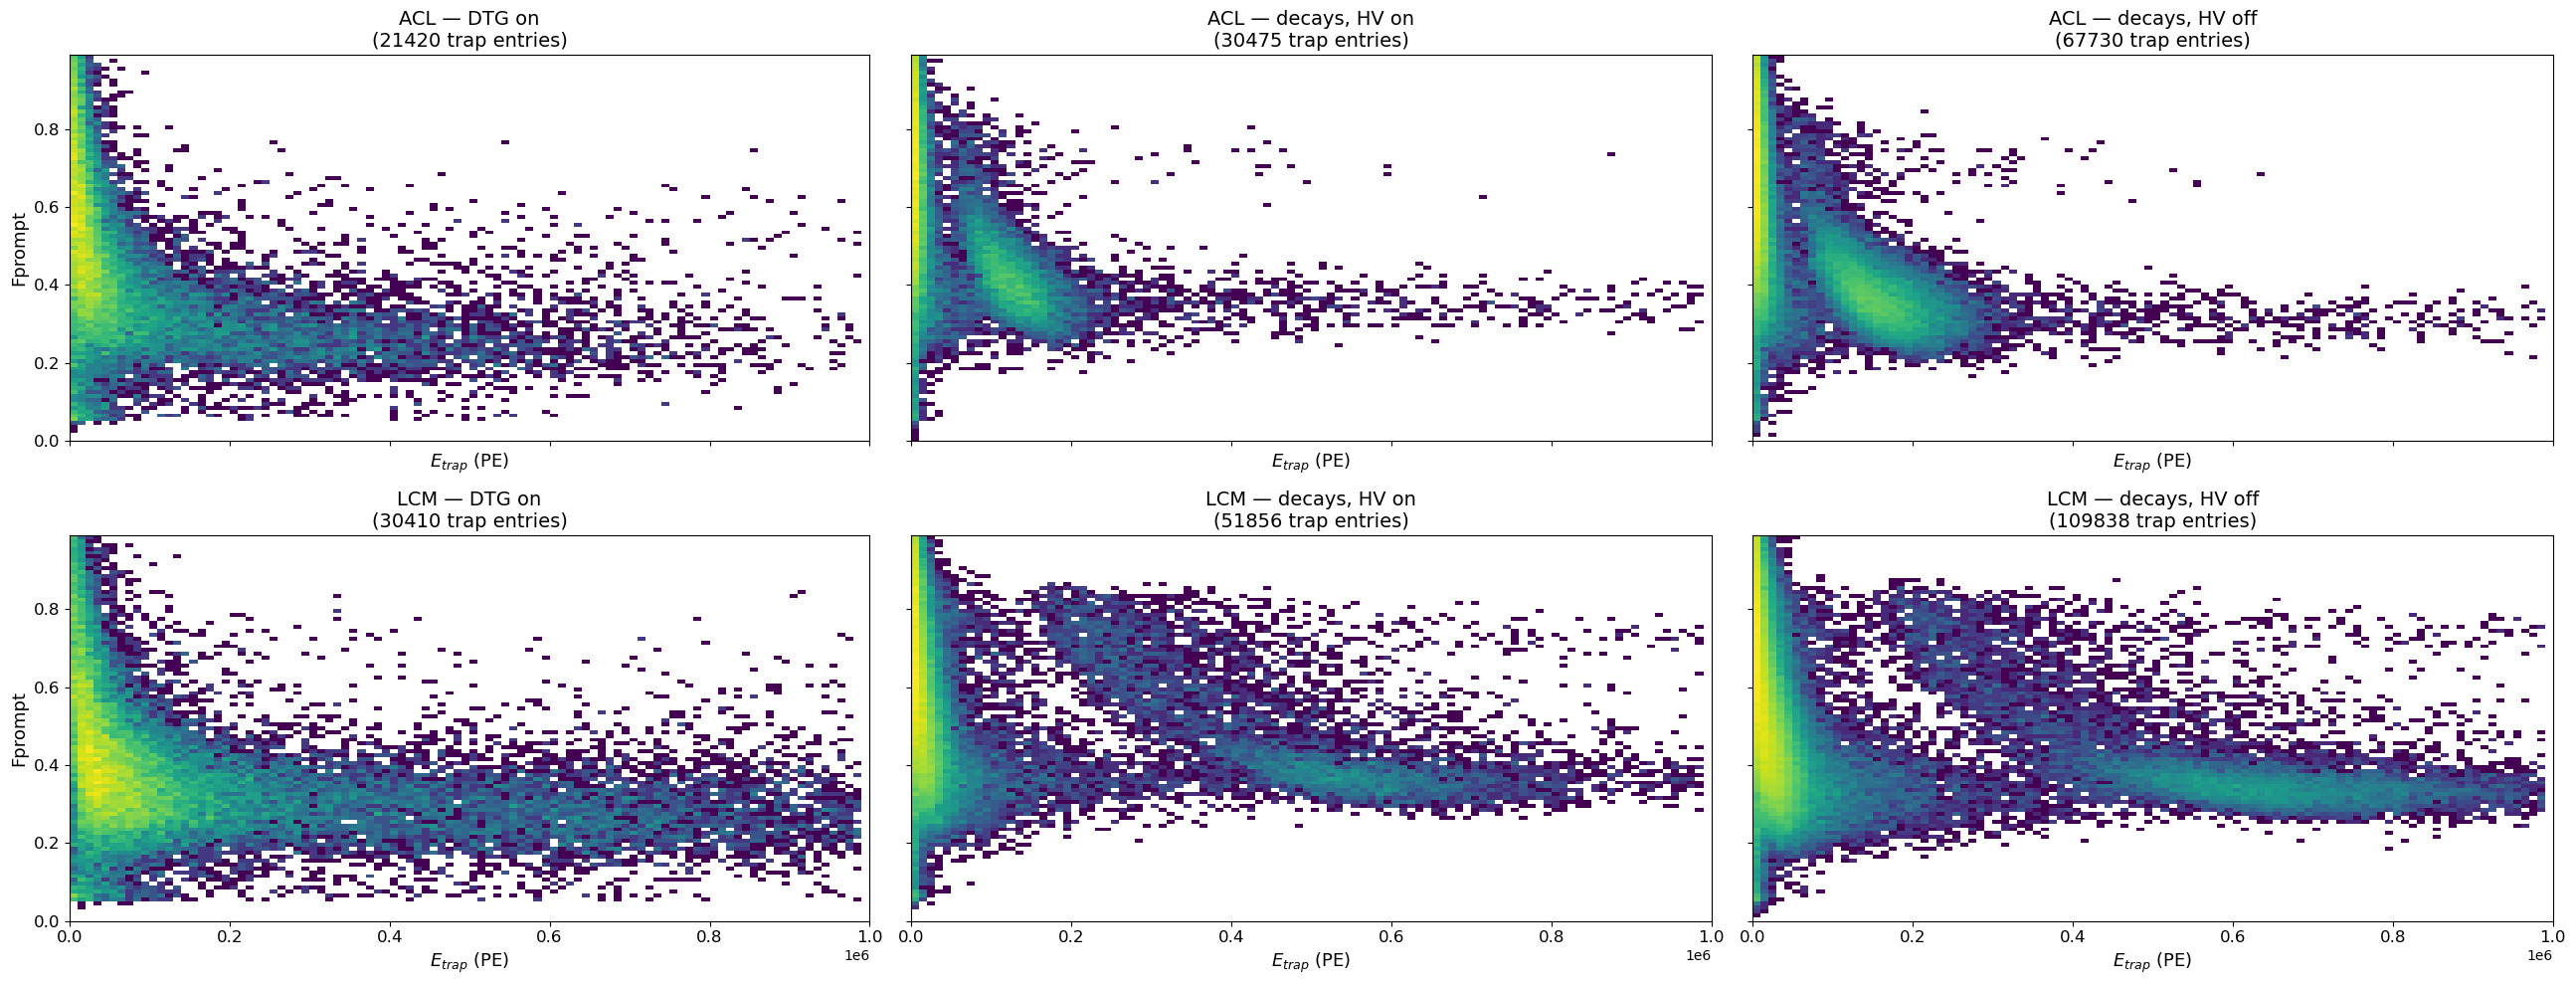

In [23]:
conditions = {
    "978": "DTG on",
    "979": "decays, HV on",
    "980": "decays, HV off",
}

detector_types = [
    ("fprompt_acl", "energy_acl", "n_peaks_acl", "ACL"),
    ("fprompt_lcm", "energy_lcm", "n_peaks_lcm", "LCM"),
]

fig, axes = plt.subplots(2, 3, figsize=(26, 10), sharey=True, sharex=True)

for row, (fp_col, en_col, np_col, det_label) in enumerate(detector_types):
    col = 0
    for key, cond_label in conditions.items():
        subset = df[df["file"].str.contains(key)]
        if len(subset) == 0:
            col += 1
            continue

        # Flatten all trap entries across all events, then mask per-trap pileup
        flat_fp  = np.concatenate(subset[fp_col].values)
        flat_en  = np.concatenate(subset[en_col].values)
        flat_np  = np.concatenate(subset[np_col].values)

        # Keep only trap entries that have exactly one peak (no pileup)
        clean = (flat_np == 1) & np.isfinite(flat_fp) & np.isfinite(flat_en)
        flat_fp = flat_fp[clean]
        flat_en = flat_en[clean]

        axes[row, col].hist2d(
            flat_en,
            flat_fp,
            bins=[np.arange(0, 1e6, 1e4), np.arange(0, 1, 0.01)],
            norm=LogNorm(),
        )
        axes[row, col].set_title(f"{det_label} — {cond_label}\n({clean.sum()} trap entries)", fontsize=14)
        axes[row, col].set_xlabel("$E_{trap}$ (PE)", fontsize=13)
        axes[row, col].tick_params(axis="both", which="major", labelsize=12)
        col += 1

    axes[row, 0].set_ylabel("Fprompt", fontsize=13)

plt.xlim(0, 1e6)
plt.tight_layout()
plt.show()
